# LeetCode #1060: Missing Element in Sorted Array

https://leetcode.com/problems/missing-element-in-sorted-array/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (linear scan)** | $O(n)$ | $O(1)$ |
| **Optimal: Binary Search on Missing Count ★** | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (linear scan)
Walk through the array counting missing numbers until the k-th one is found. $O(n)$ in the worst case (k near the end).

### Optimal: Binary Search on Missing Count ★
Define `missing(i) = nums[i] - nums[0] - i` = count of missing integers in `[nums[0], nums[i]]`. This function is monotonically non-decreasing. Binary search for the last index `lo` where `missing(lo) < k`; the answer is `nums[lo] + (k - missing(lo))`. If `k > missing(n-1)` the answer lies beyond the array.

**Constraints:**
* 1 <= nums.length <= 5 * 10^4
* 1 <= nums[i] <= 10^7
* nums is sorted in ascending order with no duplicates
* 1 <= k <= 5 * 10^8


## Solutions

### C#

In [ ]:
public int MissingElement(int[] nums, int k) {
    int n = nums.Length;
    // Count of missing integers before index i
    int Missing(int i) => nums[i] - nums[0] - i;
    // If k-th missing is beyond the last element, extend outward
    if (k > Missing(n - 1)) return nums[n - 1] + (k - Missing(n - 1));
    // Binary search: find last index where missing count < k
    int lo = 0, hi = n - 1;
    while (lo < hi - 1) {
        int mid = lo + (hi - lo) / 2;
        if (Missing(mid) < k) lo = mid;
        else hi = mid;
    }
    // The k-th missing is k - Missing(lo) steps past nums[lo]
    return nums[lo] + (k - Missing(lo));
}


### Python

In [ ]:
def missingElement(self, nums: list[int], k: int) -> int:
    n = len(nums)
    # Count of missing integers before index i
    def missing(i: int) -> int:
        return nums[i] - nums[0] - i
    # If k-th missing is beyond the last element, extend outward
    if k > missing(n - 1):
        return nums[n - 1] + (k - missing(n - 1))
    # Binary search: find last index where missing count < k
    lo, hi = 0, n - 1
    while lo < hi - 1:
        mid = lo + (hi - lo) // 2
        if missing(mid) < k:
            lo = mid
        else:
            hi = mid
    # The k-th missing is k - missing(lo) steps past nums[lo]
    return nums[lo] + (k - missing(lo))


### Go

In [ ]:
func missingElement(nums []int, k int) int {
    n := len(nums)
    // Count of missing integers before index i
    missing := func(i int) int { return nums[i] - nums[0] - i }
    // If k-th missing is beyond the last element, extend outward
    if k > missing(n-1) {
        return nums[n-1] + (k - missing(n-1))
    }
    // Binary search: find last index where missing count < k
    lo, hi := 0, n-1
    for lo < hi-1 {
        mid := lo + (hi-lo)/2
        if missing(mid) < k { lo = mid } else { hi = mid }
    }
    // The k-th missing is k - missing(lo) steps past nums[lo]
    return nums[lo] + (k - missing(lo))
}


### Rust

In [ ]:
pub fn missing_element(nums: Vec<i32>, k: i32) -> i32 {
    let n = nums.len();
    // Count of missing integers before index i
    let missing = |i: usize| (nums[i] - nums[0]) as i64 - i as i64;
    // If k-th missing is beyond the last element, extend outward
    if k as i64 > missing(n - 1) {
        return nums[n - 1] + (k - missing(n - 1) as i32);
    }
    // Binary search: find last index where missing count < k
    let (mut lo, mut hi) = (0usize, n - 1);
    while lo < hi - 1 {
        let mid = lo + (hi - lo) / 2;
        if missing(mid) < k as i64 { lo = mid; } else { hi = mid; }
    }
    // The k-th missing is k - missing(lo) steps past nums[lo]
    nums[lo] + (k - missing(lo) as i32)
}


## Example Scenarios

**1. Common Case**
**Input:** nums = [4, 7, 9, 10], k = 1
missing(0)=0, missing(3)=10-4-3=3≥1. Binary search: lo=0,hi=3. mid=1: missing(1)=7-4-1=2≥1→hi=1. lo=0<hi-1=0? No → done. Return nums[0]+(1-0)=4+1=5. The first missing number after 4 is 5.

**2. Slightly Complex**
**Input:** nums = [4, 7, 9, 10], k = 3
missing(3)=3≥3 so answer is within range. Binary search: mid=1: missing(1)=2<3→lo=1; lo=1,hi=3,mid=2: missing(2)=9-4-2=3≥3→hi=2; lo=1,hi-1=1 → done. Return nums[1]+(3-2)=7+1=8. Verified: missing numbers after 4 are 5,6,8 — 3rd is 8.

**3. Edge Case: Time Factor**
**Input:** nums = [1, 2, 3, ..., 50000], k = 5*10^8 (all missing are beyond array)
missing(n-1)=50000-1-49999=0 < 5×10^8 → beyond. Return nums[n-1]+(k-0)=50000+5×10^8. No binary search needed — single check.

**4. Edge Case: Space Factor**
**Input:** nums = [1], k = 1
missing(0)=0 < k=1 → beyond. Return 1+(1-0)=2. $O(1)$ space: missing function, lo, hi, mid are all scalars.

**5. Almost-Impossible but Plausible**
**Input:** nums = [1, 10000000], k = 9999997
missing(1)=10^7-1-1=9999998≥k. Binary search on 2 elements: lo=0,hi=1, lo<hi-1=0 is false immediately. Return nums[0]+(k-0)=1+9999997=9999998. Verify: integers missing between 1 and 10^7 are 2..9999999 — the 9999997th is 9999998 ✓.


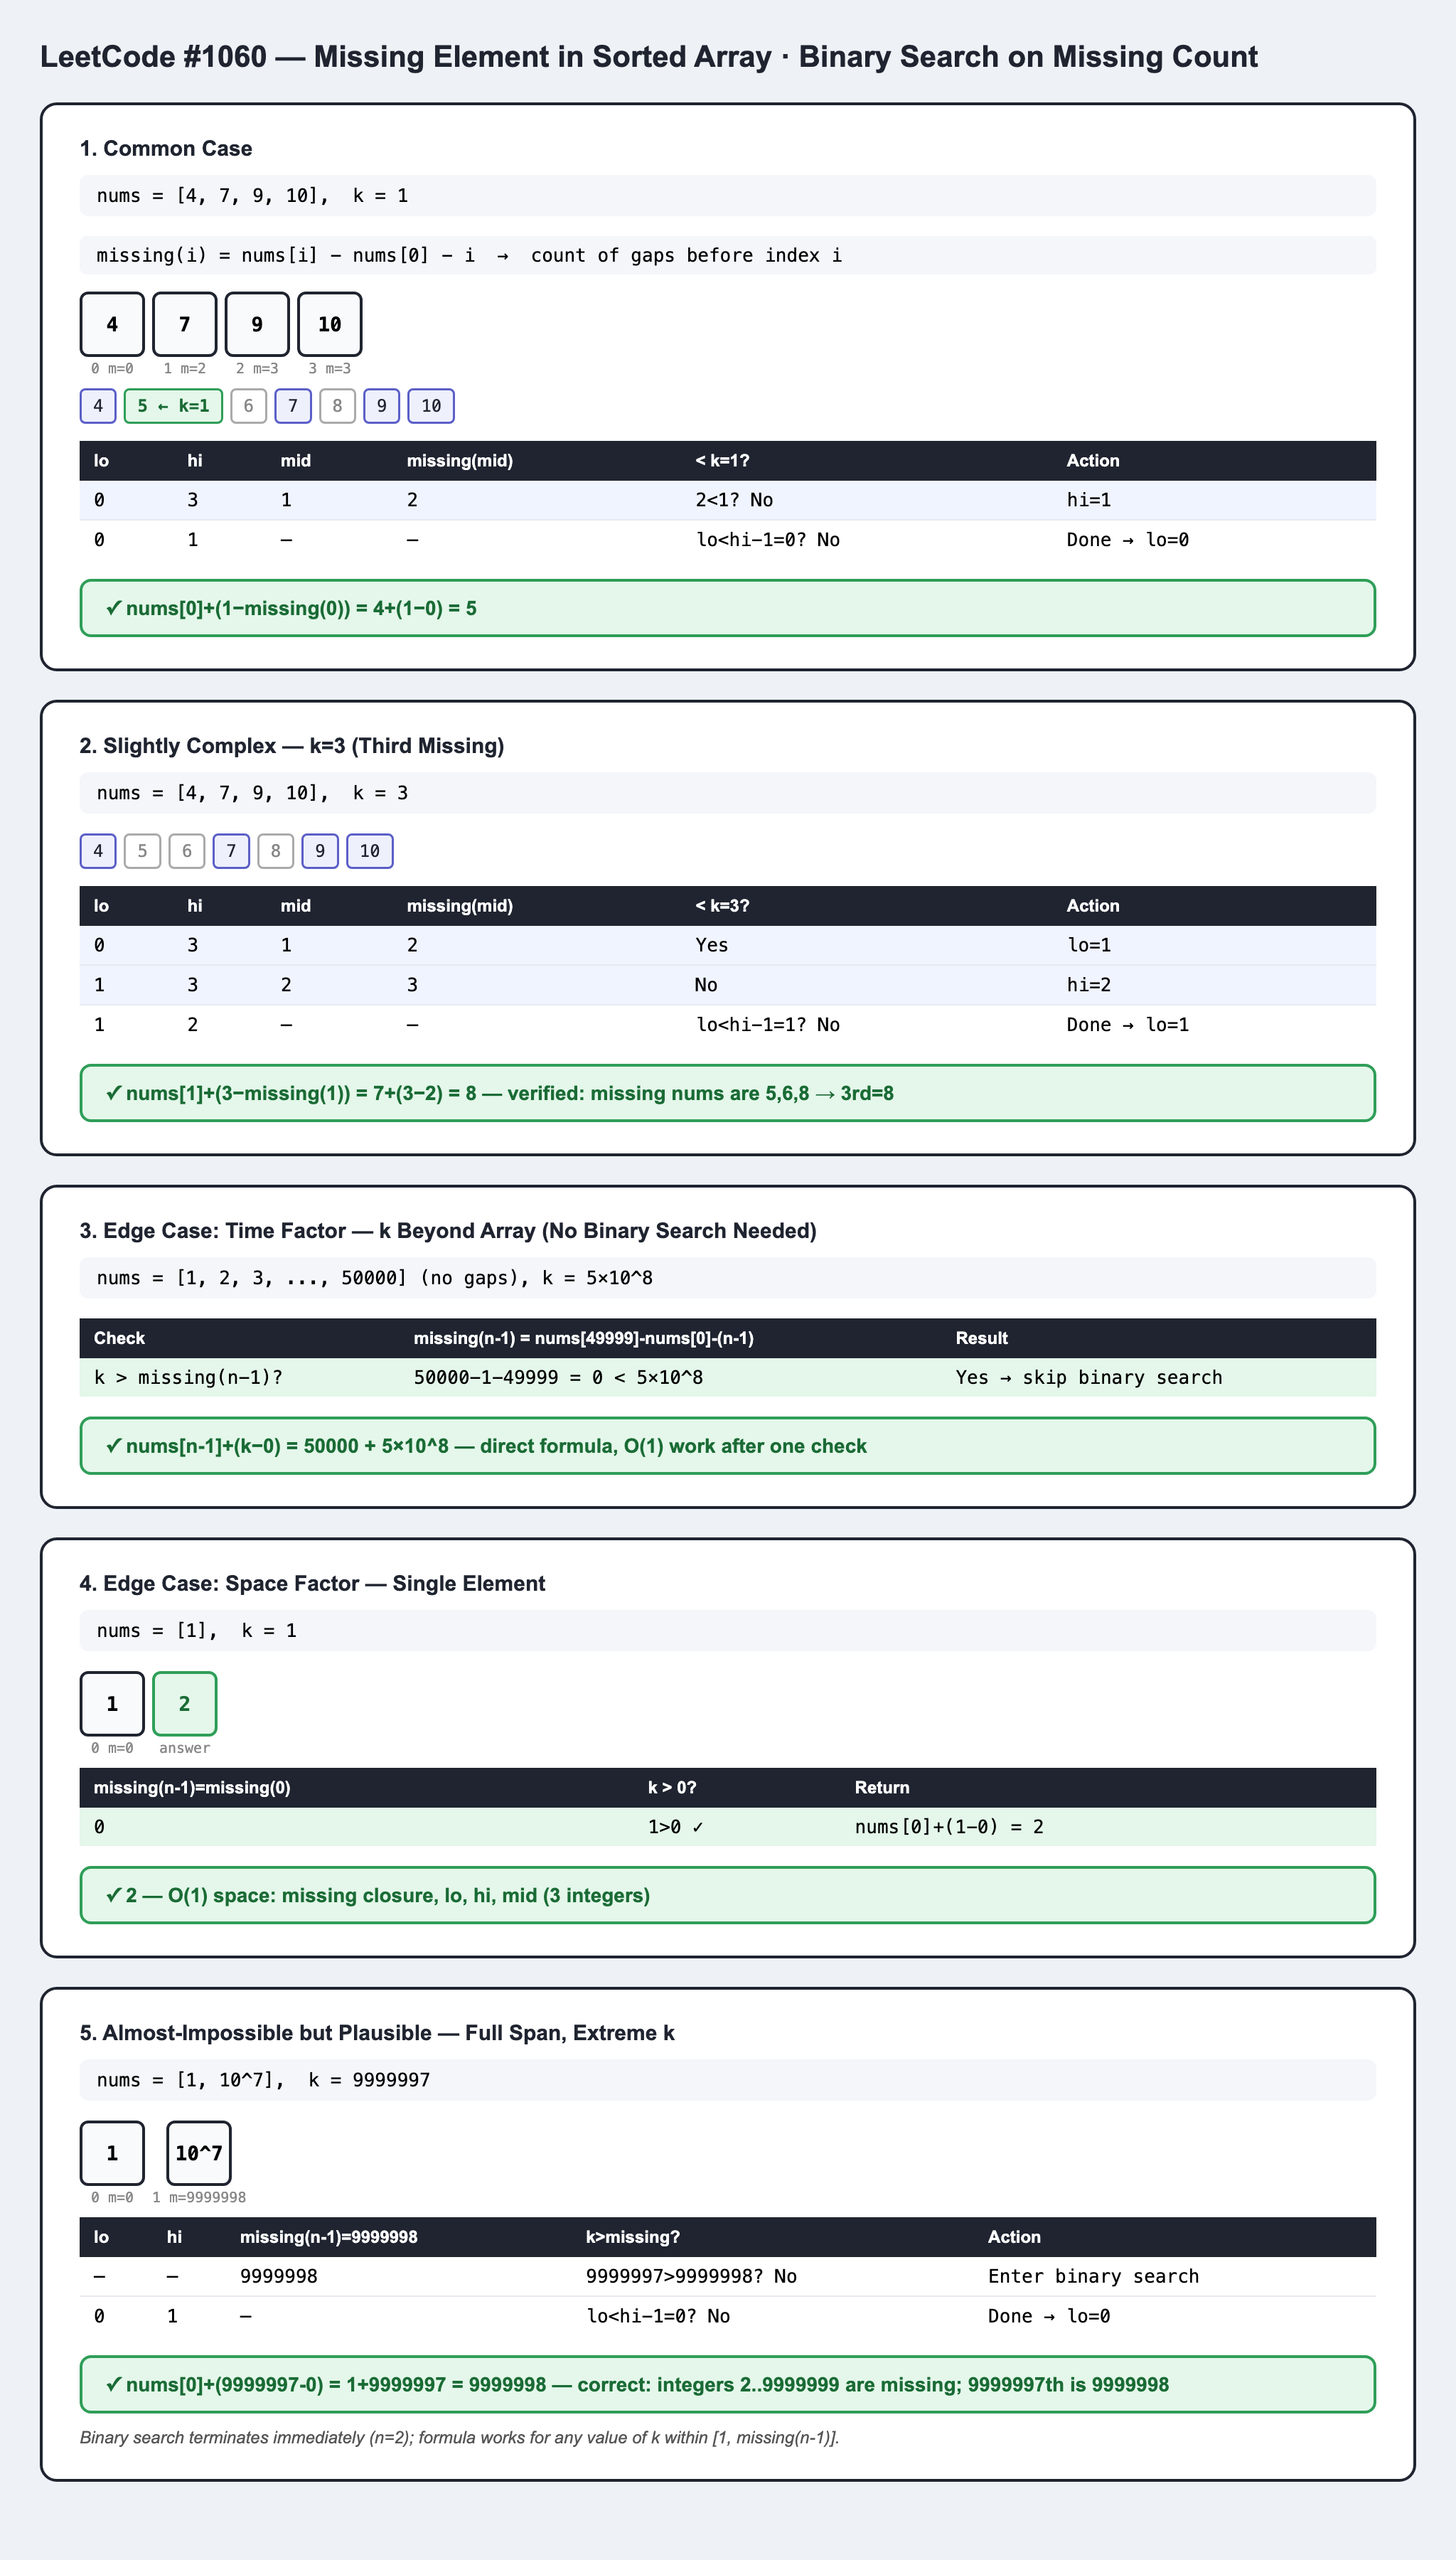